# 3.데이터분석_이변량분석(범주vs숫자)

## 3.1.환경준비

### **3.1.1. 라이브러리 불러오기**

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as spst

### **3.1.2. 데이터 불러오기**

- 타이타닉 생존자 : 'titanic_train.csv'

|	변수	|	설명	|	값 설명	|
|	----	|	----	|	----	|
|	survived	|	생존여부	|	0 - 사망, 1- 생존	|
|	Pclass	|	Ticket class	|	1 = 1st, 2 = 2nd, 3 = 3rd	|
|	Sex	|	성별	|		|
|	Age	|	Age in years	|		|
|	Sibsp	|	# of siblings / spouses aboard the Titanic	|		|
|	Parch	|	# of parents / children aboard the Titanic	|		|
|	Ticket	|	Ticket number	|		|
|	Fare	|	Passenger fare	|		|
|	Cabin	|	Cabin number	|		|
|	Embarked	|	Port of Embarkation	|	C = Cherbourg, Q = Queenstown, S = Southampton	|


In [27]:
titanic = pd.read_csv('data/titanic_train.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---

- 범주별 숫자를 비교할 때 사용되는 방식은 **범주별 평균 비교** 이다.


## 3.2.시각화
- titanic data에서 Age를 Y로 두고 비교해 봅시다.

### 3.2.1. barplot

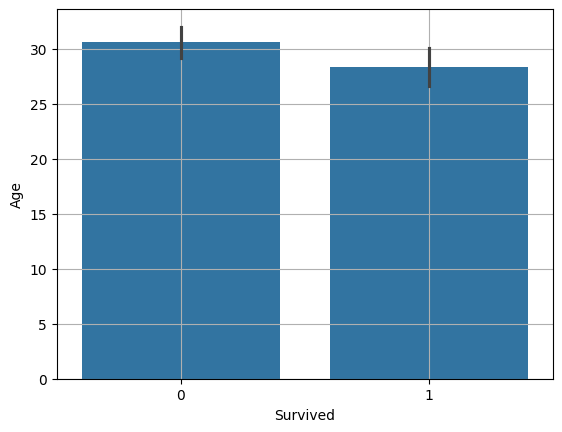

In [28]:
sns.barplot(x='Survived', y='Age', data=titanic)
plt.grid()
plt.show()                    

1. 막대 그래프의 높이 
    - 각 막대는 해당 그룹(생존자, 사망자)의 평균 나이를 나타냄
2. 신뢰 구간(오차범위)
    - 막대 위의 세로선은 신뢰구간을 의미. 95% 신뢰구간: 평균 나이가 이 구간안에 있을 확률이 95%임.
3. 해석 
    - 생존자는 평균적으로 더 어리지만, 이 차이가 통계적으로 유의미한지는 추가 검정(t-test)이 필요.

위 두 범주간에 평균에 차이가 있나요?

- 데이터 분석에서는 두 집단(예: 생존자 vs 사망자) 간에 어떤 차이가 있는지 확인해야 할 때가 많음.
- 예를 들어: 타이타닉호 생존 여부에 따라 평균 나이에 차이가 있을까?
- 대립 가설 : 생존 여부에 따라 나이의 차이가 있다.

### 3.2.2. boxplot

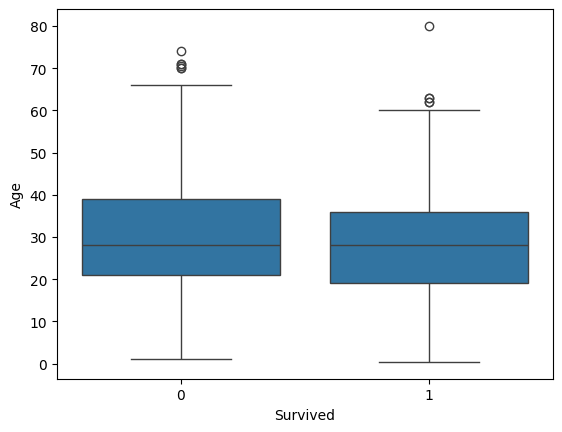

In [29]:
sns.boxplot(x='Survived', y='Age', data=titanic)
plt.show()

## 3.3.수치화

### 3.3.1. t-test

- 두 집단의 평균 비교
    - 예제는 Two sample T-test와 양측검정만 다룬다.
    - 우리는 X --> Y의 관계에서 ,두 변수간에 관련이(차이가) 있는지, 없는지를 확인하는 것이 제일 중요하기 때문이다.

- 주의사항 : 데이터에 NaN이 있으면 계산이 안된다. `.notnull()` 등으로 NaN을 제외한 데이터를 사용해야 한다.

- t 통계량(t-statistic)
    - 두 집단의 평균 차이를 표준오차로 나눈 값
    - 기본적으로는 두 평균의 차이로 이해해도 좋다.
    - 우리의 가설(대립가설)은 차이가 있다는 것이므로, t 값이 크던지 작던지 하기를 바란다.
    - 보통, t 값이 -2보다 작거나, 2보다 크면 차이가 있다고 본다.

* 이번엔 타이타닉 데이터로 시도해 봅시다.
    * 생존여부 --> Age : 생존여부 별로 나이에 차이가 있을것이다.


**1) 데이터 준비**

In [30]:
# 먼저 NaN이 있는지 확인
titanic.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [31]:
# NaN 행 제외
temp = titanic.loc[titanic['Age'].notnull()]

In [32]:
# 두 그룹으로 데이터 저장
died = temp.loc[temp['Survived']==0, 'Age']
survived = temp.loc[temp['Survived']==1, 'Age']

**2) t-test**

- 귀무가설 : 타이타닉 탑승객 생존 여부별 나이의 차이가 없다.
- 대립가설 : 생존여부에 따른 나이의 차이가 있다.

- 기본 문법 : `ttest_ind(B,A, equal_var=False)`
    - A와 비교할 때 B의 평균이 큰가?
    - equal_var : A와 B의 분산이 같은가?
        - 모르면 False(default)

In [33]:
spst.ttest_ind(died, survived)

TtestResult(statistic=np.float64(2.06668694625381), pvalue=np.float64(0.039124654013482474), df=np.float64(712.0))

In [34]:
# t-통계량 : 2.066 -> 2보다 크므로, 차이가 있기는 있으나 크지는 않다.
# p-value : 0.039 -> 0.05보다 작으므로, 귀무가설을 기각하고, 통계적으로 유의미하다.

**<연습문제>**

[문1] 성별에 따라 운임에 차이가 있을 것이다.

- 귀무가설 : 타이타닉 탑승객 성별에 따른 운임의 차이가 없다.
- 대립가설 : 성별에 따른 운임의 차이가 있을 것이다.

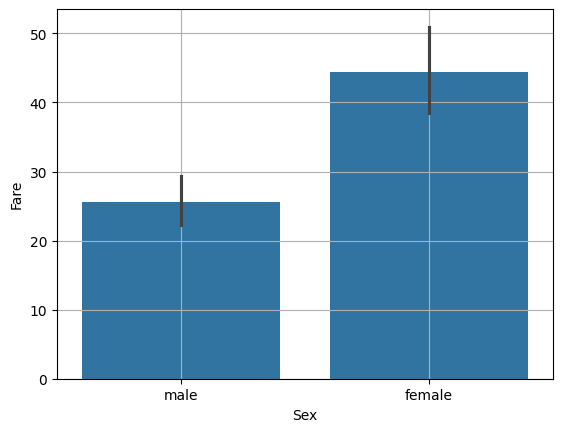

In [35]:
sns.barplot(x='Sex', y='Fare', data=titanic)
plt.grid()
plt.show()                    

In [36]:
# 두 그룹으로 데이터 저장
male_fare = titanic.loc[titanic['Sex']=='male', 'Fare']
female_fare = titanic.loc[titanic['Sex']=='female', 'Fare']

spst.ttest_ind(male_fare,female_fare)

TtestResult(statistic=np.float64(-5.529140269385719), pvalue=np.float64(4.230867870043005e-08), df=np.float64(889.0))

In [37]:
# 두 집단의 평균 요금 차이는 '우연이 아니라 확실한 차이'
# 여성이 남성보다 요금을 더 많이 냈다.
# 통계적으로 남성이 여성의 평균 요금은 유의미하게 다르다.

[문2] 생존여부에 따라 운임에 차이가 있을 것이다.

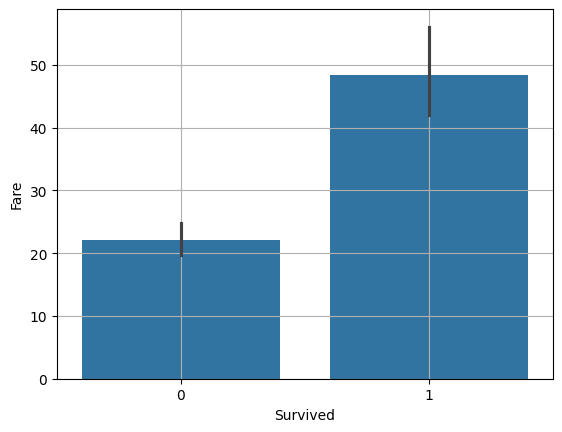

In [38]:
sns.barplot(x='Survived', y='Fare', data=titanic)
plt.grid()
plt.show()                    

In [39]:
# 두 그룹으로 데이터 저장
d_fare = titanic.loc[titanic['Survived']==0, 'Fare']
s_fare = titanic.loc[titanic['Survived']==1, 'Fare']

spst.ttest_ind(d_fare,s_fare)

# 해석: 두 그룹 간 운임 평균의 차이는 통계적으로 유의미하다.

TtestResult(statistic=np.float64(-7.939191660871055), pvalue=np.float64(6.1201893419242075e-15), df=np.float64(889.0))

### **3.3.2. anova**

- 분산 분석 **AN**alysis **O**f **VA**riance
    - **ANOVA (Analysis of Variance)** 는 셋 이상 집단의 평균 차이가 통계적으로 유의미한지를 검정하는 방법
    - 여러 집단 간에 차이는 어떻게 비교할 수 있을까?
    - 여기서 기준은 **전체 평균** 이다.


$
F \text{ 통계량} = \frac{\text{집단 간 분산}}{\text{집단 내 분산}} =\frac{\text{전체 평균 - 각 집단 평균}}{\text{각 집단의 평균 - 개별 값}}
$

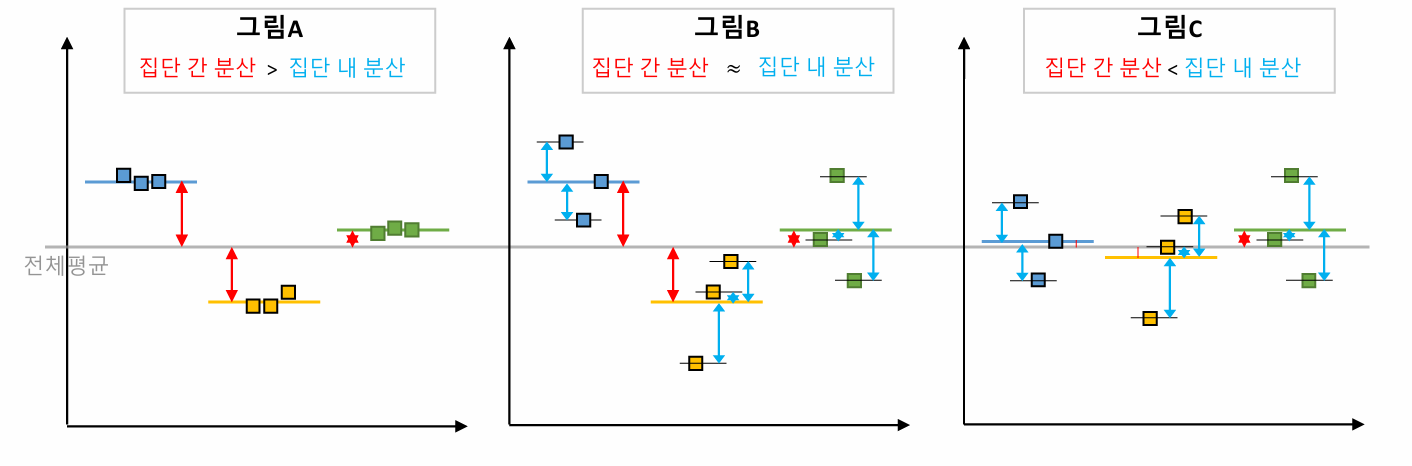

- f분포
    - 두 개의 독립된 정규분포를 따르는 모집단의 분산 비율로 만들어지는 확률 분포
    - 오른쪽으로 길게 늘어진 비대칭 분포를 가지며, 0에서 시작해서 무한대로 이어짐
    - 값이 대략 2~3 이상이면 차이가 있다고 판단한다.

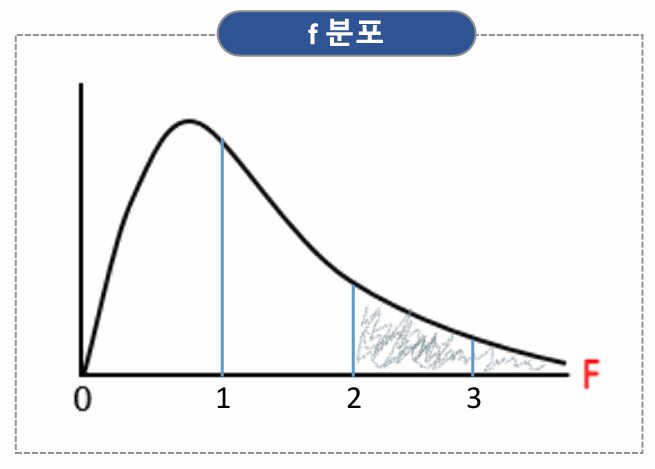

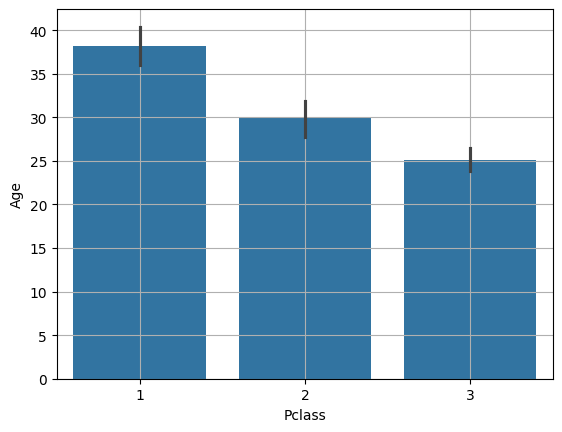

In [40]:
# Pclass(3 범주) -> Age
sns.barplot(x='Pclass', y='Age', data=titanic)
plt.grid()
plt.show()

**1) 데이터 준비**

In [41]:
# 분산 분석을 위한 데이터를 만들기
# NaN 행 제외
temp = titanic.loc[titanic['Age'].notnull()]

# 그룹별 저장
# 각 그룹(=집단)의 분포를 따로 분리해서 비교하기 위함
p_1 = temp.loc[temp['Pclass']==1, 'Age']
p_2 = temp.loc[temp['Pclass']==2, 'Age']
p_3 = temp.loc[temp['Pclass']==3, 'Age']

**2) anova**

In [43]:
f_statistic, p_value = spst.f_oneway(p_1, p_2, p_3)

In [ ]:
# ANOVA 수행
print('F-statistic:', f_statistic)
print('p_value', p_value)

# F-통계량 : 57.44 -> 세 집단 간의 평균 차이가 꽤 큼을 나타냄.
# p-value : 0.05보다 작기 때문에 귀무가설 기각. 통계적으로 유의하다.

F-statistic: 57.44348434067624
p_value 7.487984171957403e-24


**<연습문제>**

[문1] 승선지역(Embarked)별로 운임에 차이가 있을 것이다.
- 시각화와 수치화로 확인해 봅시다.

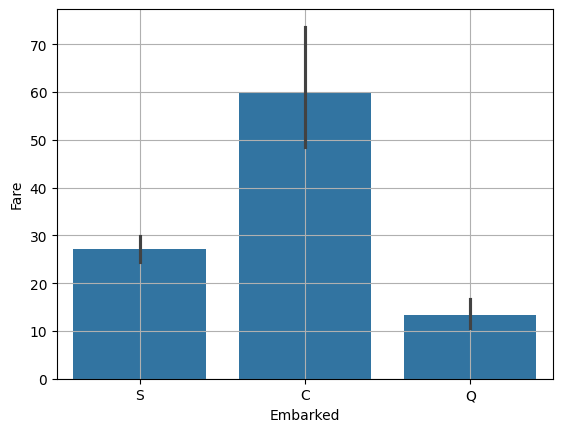

In [45]:
sns.barplot(x='Embarked', y='Fare', data=titanic)
plt.grid()
plt.show()                    

In [50]:
# 세 그룹으로 데이터 저장
qq_fare = titanic.loc[titanic['Embarked']=='Q', 'Fare']
cc_fare = titanic.loc[titanic['Embarked']=='C', 'Fare']
ss_fare = titanic.loc[titanic['Embarked']=='S', 'Fare']

spst.f_oneway(qq_fare, cc_fare, ss_fare)

F_onewayResult(statistic=np.float64(38.140305200112664), pvalue=np.float64(1.2896450252637108e-16))

[문2] 객실등급(Pclass)별로 운임에 차이가 있을 것이다.
- 시각화와 수치화로 확인해 봅시다.

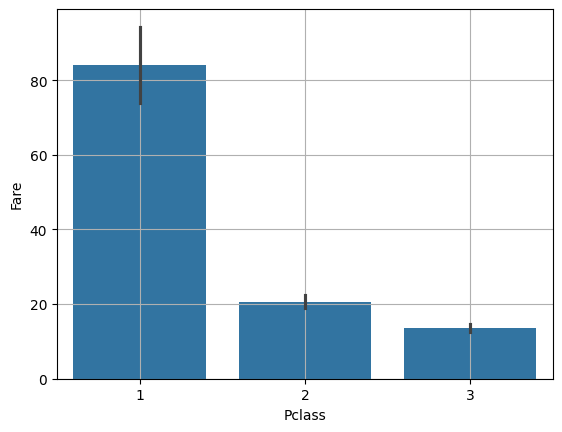

In [51]:
sns.barplot(x='Pclass', y='Fare', data=titanic)
plt.grid()
plt.show()                    

In [52]:
# 세 그룹으로 데이터 저장
fare_1 = titanic.loc[titanic['Pclass']==1, 'Fare']
fare_2 = titanic.loc[titanic['Pclass']==2, 'Fare']
fare_3 = titanic.loc[titanic['Pclass']==3, 'Fare']

spst.f_oneway(fare_1, fare_2, fare_3)

F_onewayResult(statistic=np.float64(242.34415651744814), pvalue=np.float64(1.031376320913912e-84))

## 3.4.종합 연습문제

air quality 데이터셋으로 다음 문제를 풀어 봅시다.

* 라이브러리 불러오기

* 데이터불러오기

In [62]:
air = pd.read_csv('data/airquality2.csv')
air.isna().sum()

air

,Ozone,Solar.R,Wind,Temp,Date
0,41,190.0,7.4,67,1973-05-01
1,36,118.0,8.0,72,1973-05-02
2,12,149.0,12.6,74,1973-05-03
3,18,313.0,11.5,62,1973-05-04
4,19,NaN,14.3,56,1973-05-05
...,...,...,...,...,...
148,30,193.0,6.9,70,1973-09-26
149,23,145.0,13.2,77,1973-09-27
150,14,191.0,14.3,75,1973-09-28
151,18,131.0,8.0,76,1973-09-29


In [56]:
air.info()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    153 non-null    int64  
 1   Solar.R  146 non-null    float64
 2   Wind     153 non-null    float64
 3   Temp     153 non-null    int64  
 4   Date     153 non-null    str    
dtypes: float64(2), int64(2), str(1)
memory usage: 6.1 KB


In [84]:
air['Date'] = pd.to_datetime(air['Date'])
air['Month'] = air.Date.dt.month
air['Weekday'] = air.Date.dt.weekday

# 월화수목금 토일 : 01234 56
# 주말 -> 1, 평일 -> 0
air['Weekend'] = (air['Weekday'] >= 5).astype(int)

air.head()

,Ozone,Solar.R,Wind,Temp,Date,Month,Weekday,Weekend
0,41,190.0,7.4,67,1973-05-01,5,1,0
1,36,118.0,8.0,72,1973-05-02,5,2,0
2,12,149.0,12.6,74,1973-05-03,5,3,0
3,18,313.0,11.5,62,1973-05-04,5,4,0
4,19,NaN,14.3,56,1973-05-05,5,5,1


* 1) 주말여부(Weekend) --> 오존농도(Ozone)와의 관계를 시각화하고, 가설검정을 수행해 봅시다.

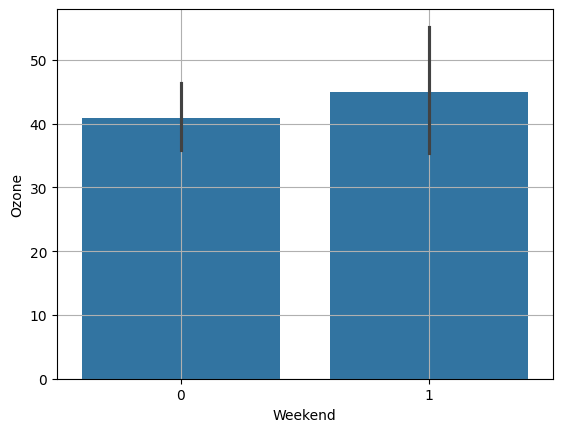

In [85]:
# 시각화
sns.barplot(x='Weekend', y='Ozone', data=air)
plt.grid()
plt.show()

In [86]:
weekday_0 = air.loc[air['Weekend']==0, 'Ozone']
weekday_1 = air.loc[air['Weekend']==1, 'Ozone']

spst.ttest_ind(weekday_0,weekday_1)

TtestResult(statistic=np.float64(-0.7671489829911908), pvalue=np.float64(0.4441907648291732), df=np.float64(151.0))

* 2) 요일(Weekday) --> 오존농도(Ozone)와의 관계를 시각화하고, 가설검정을 수행해 봅시다.

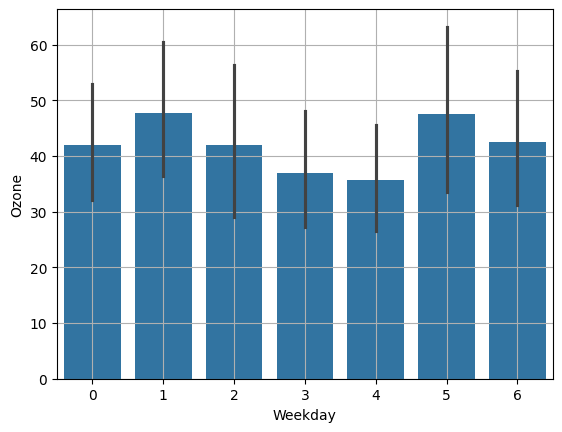

In [87]:
sns.barplot(x='Weekday', y='Ozone', data=air)
plt.grid()
plt.show()

In [88]:
we_0 = air.loc[air['Weekday']==0, 'Ozone']
we_1 = air.loc[air['Weekday']==1, 'Ozone']
we_2 = air.loc[air['Weekday']==2, 'Ozone']
we_3 = air.loc[air['Weekday']==3, 'Ozone']
we_4 = air.loc[air['Weekday']==4, 'Ozone']
we_5 = air.loc[air['Weekday']==5, 'Ozone']
we_6 = air.loc[air['Weekday']==6, 'Ozone']

spst.f_oneway(we_0,we_1,we_2,we_3,we_4,we_5,we_6)

F_onewayResult(statistic=np.float64(0.5098923426664417), pvalue=np.float64(0.8001433644111912))

* 3) 월(Month) --> 오존농도(Ozone)와의 관계를 시각화하고, 가설검정을 수행해 봅시다.

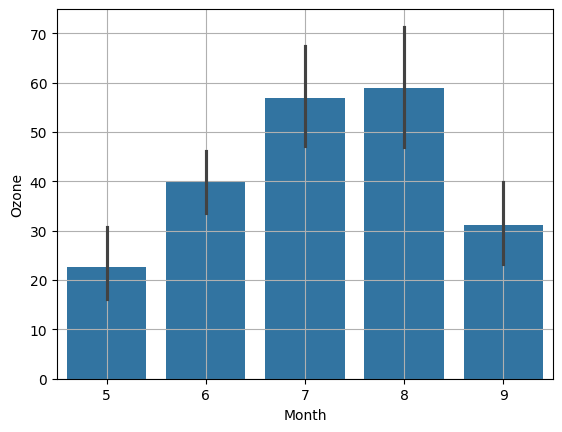

In [89]:
sns.barplot(x="Month", y="Ozone", data= air)
plt.grid()
plt.show()

In [90]:
w_5 = air.loc[air['Month']==5, 'Ozone']
w_6 = air.loc[air['Month']==6, 'Ozone']
w_7 = air.loc[air['Month']==7, 'Ozone']
w_8 = air.loc[air['Month']==8, 'Ozone']
w_9 = air.loc[air['Month']==9, 'Ozone']

spst.f_oneway(w_5, w_6,w_7, w_8,w_9)

F_onewayResult(statistic=np.float64(10.702965130677125), pvalue=np.float64(1.202707995452932e-07))